In [ ]:
import pandas as _hex_pandas
import datetime as _hex_datetime
import json as _hex_json

In [ ]:
hex_scheduled = _hex_json.loads("false")

In [ ]:
hex_user_email = _hex_json.loads("\"example-user@example.com\"")

In [ ]:
hex_user_attributes = _hex_json.loads("{}")

In [ ]:
hex_run_context = _hex_json.loads("\"logic\"")

In [ ]:
hex_timezone = _hex_json.loads("\"UTC\"")

In [ ]:
hex_project_id = _hex_json.loads("\"9b7007d9-a15f-4317-8c28-37558a074064\"")

In [ ]:
hex_project_name = _hex_json.loads("\"Detecting Anomalies in NYC Taxi Ridership\"")

In [ ]:
hex_status = _hex_json.loads("\"\"")

In [ ]:
hex_categories = _hex_json.loads("[]")

In [ ]:
hex_color_palette = _hex_json.loads("[\"#4C78A8\",\"#F58518\",\"#E45756\",\"#72B7B2\",\"#54A24B\",\"#EECA3B\",\"#B279A2\",\"#FF9DA6\",\"#9D755D\",\"#BAB0AC\"]")

In the hustle and bustle of the city that never sleeps, New York City's taxi cabs are a constant presence, ferrying passengers from one destination to another at all hours. With over 13,000 yellow taxis in operation, these vehicles serve hundreds of thousands of people daily, and their ridership data can provide us with fascinating insights into the city's rhythm and pulse.

In this project, we explore a dataset that aggregates the total number of taxi passengers into 30-minute intervals. This data, sourced from the NYC Taxi and Limousine Commission [via the NAB project](https://github.com/numenta/NAB/tree/master/data), provides us with a time-series view of taxi usage in the city over several months. 

Anomalies, or significant deviations from the norm, within this dataset often correspond to city-wide events or special circumstances. For instance, events like the NYC marathon or major holidays, which disrupt regular city activity, can cause noticeable spikes or dips in taxi ridership. By detecting these anomalies, we can indirectly identify these city-wide events and gain insights into their impact on the city's transportation dynamics.With this context, let's start our exploration of the NYC taxi ridership data.



### Exploring the data



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv("Detecting Anomalies in NYC Taxi Ridership.csv")

# Convert the timestamp to datetime and set it as the index
df["timestamp"] = pd.to_datetime(df["timestamp"])
# df.set_index('timestamp', inplace=True)

# Display the first few rows of the dataset
df.head()

,timestamp,value
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820


Our dataset contains two columns: `**timestamp**` and `**value**`. The `**timestamp**` column has been set as the index of our DataFrame and represents the time at which the data was collected, in 30-minute intervals. The `**value**` column represents the number of taxi passengers during each interval.Let's examine the statistical properties of our dataset and visualize the time series.



In [ ]:
df.describe()

,value,hour,day_of_week
count,10320.000000,10320.000000,10320.000000
mean,15137.569380,11.500000,3.000000
std,6939.495808,6.922522,1.988434
min,8.000000,0.000000,0.000000
25%,10262.000000,5.750000,1.000000
50%,16778.000000,11.500000,3.000000
75%,19838.750000,17.250000,5.000000
max,39197.000000,23.000000,6.000000


In [ ]:
import altair
chart_df = altair.Chart.from_json(r"""
{
    "width": "container",
    "height": "container",
    "$schema": "https://vega.github.io/schema/vega-lite/v5.json",
    "layer": [
        {
            "description": "outer data layer",
            "resolve": {
                "scale": {
                    "color": "independent",
                    "y": "shared"
                }
            },
            "layer": [
                {
                    "description": "series data layer",
                    "name": "series_12fe0eb0-63bc-41b2-b6ea-d57d877ee6c0",
                    "layer": [
                        {
                            "description": "line series layer",
                            "transform": [
                                {
                                    "calculate": "toDate(datum[\"timestamp\"])",
                                    "as": "timestamp"
                                },
                                {
                                    "filter": "isValid(datum[\"timestamp\"])"
                                }
                            ],
                            "layer": [
                                {
                                    "description": "line mark layer",
                                    "mark": {
                                        "type": "line",
                                        "point": false,
                                        "clip": true,
                                        "strokeCap": "square",
                                        "strokeJoin": "round",
                                        "cursor": "crosshair"
                                    },
                                    "encoding": {
                                        "opacity": {
                                            "value": 1
                                        }
                                    }
                                },
                                {
                                    "description": "pivot tooltip point mark layer",
                                    "mark": {
                                        "type": "point",
                                        "tooltip": false,
                                        "clip": true
                                    },
                                    "encoding": {
                                        "opacity": {
                                            "value": 0,
                                            "condition": {
                                                "param": "pivot_hover_12fe0eb0-63bc-41b2-b6ea-d57d877ee6c0",
                                                "value": 1,
                                                "empty": false
                                            }
                                        },
                                        "size": {
                                            "value": 80
                                        }
                                    }
                                },
                                {
                                    "description": "pivot tooltip rule mark layer",
                                    "mark": {
                                        "type": "rule",
                                        "clip": true
                                    },
                                    "encoding": {
                                        "opacity": {
                                            "condition": {
                                                "value": 0.3,
                                                "param": "pivot_hover_12fe0eb0-63bc-41b2-b6ea-d57d877ee6c0",
                                                "empty": false
                                            },
                                            "value": 0
                                        },
                                        "color": {
                                            "value": "CHART_DEFAULT_RULE_COLOR_MARKER"
                                        },
                                        "y": null,
                                        "tooltip": [
                                            {
                                                "field": "timestamp",
                                                "type": "temporal",
                                                "timeUnit": "yearmonthdatehours",
                                                "title": "timestamp"
                                            },
                                            {
                                                "field": "value",
                                                "type": "quantitative",
                                                "aggregate": "sum",
                                                "formatType": "NUMBER_FORMATTER",
                                                "format": {
                                                    "format": "NUMBER",
                                                    "columnType": "NUMBER",
                                                    "numDecimalDigits": -1,
                                                    "currency": "USD",
                                                    "nanFormat": ""
                                                },
                                                "title": "Sum of value"
                                            }
                                        ]
                                    },
                                    "params": [
                                        {
                                            "name": "pivot_hover_12fe0eb0-63bc-41b2-b6ea-d57d877ee6c0",
                                            "select": {
                                                "type": "point",
                                                "on": "mouseover",
                                                "clear": "mouseout",
                                                "nearest": true,
                                                "fields": [
                                                    "timestamp"
                                                ]
                                            }
                                        }
                                    ]
                                }
                            ],
                            "encoding": {
                                "x": {
                                    "field": "timestamp",
                                    "type": "temporal",
                                    "title": "timestamp (year-month-date-hours)",
                                    "scale": {},
                                    "axis": {
                                        "grid": true,
                                        "ticks": true,
                                        "tickCount": {
                                            "expr": "length(domain('x')) > 0 ? min(ceil(width / 40), ceil((domain('x')[1] - domain('x')[0]) / 3600000)) : ceil(width / 40)"
                                        },
                                        "labels": true,
                                        "labelFlush": false
                                    },
                                    "timeUnit": "yearmonthdatehours"
                                },
                                "y": {
                                    "field": "value",
                                    "type": "quantitative",
                                    "aggregate": "sum",
                                    "title": "Sum of value",
                                    "scale": {
                                        "domainMin": -100
                                    },
                                    "axis": {
                                        "grid": true,
                                        "ticks": true,
                                        "labels": true,
                                        "labelFlush": false,
                                        "format": {
                                            "format": "NUMBER",
                                            "columnType": "NUMBER",
                                            "numDecimalDigits": -1,
                                            "currency": "USD",
                                            "nanFormat": ""
                                        },
                                        "formatType": "NUMBER_FORMATTER"
                                    }
                                },
                                "color": {
                                    "value": "#4C78A8"
                                }
                            }
                        }
                    ]
                }
            ],
            "transform": []
        }
    ],
    "config": {
        "legend": {
            "orient": "right"
        },
        "font": "\"IBM Plex Sans\", system-ui, -apple-system, BlinkMacSystemFont, sans-serif",
        "view": {}
    },
    "datasets": {
        "layer00": [
            {
                "name": "dummy",
                "value": 0
            }
        ]
    },
    "usermeta": {
        "selectionConfigs": {},
        "columnNameMappings": {
            "CHART_FOLD_KEYS": "Column",
            "CHART_FOLD_VALUES": "Values"
        }
    }
}
""")
chart_df.datasets.layer00 = df.to_json(orient='records')
chart_df.display(actions=False)

**Some quick facts:**

- Our dataset records the number of NYC taxi passengers in half-hour intervals from July 1, 2014, to January 31, 2015. 
- During this period, there were on average around 15,137 passengers per half-hour, with a standard deviation of 6,939 passengers.

**The time series graph reveals several interesting patterns in the data: **

- First, we see a clear daily rhythm, with peaks and troughs corresponding to the city's rush hours and off-peak times. 
- Second, there's a noticeable week-to-week pattern, with certain days of the week consistently showing higher ridership than others. 
- Finally, there are several prominent spikes in the data, which represent unusually high taxi demand. These spikes are likely the anomalies we're interested in, as they could correspond to city-wide events or special circumstances.



Next, let's perform some feature engineering to further enhance our understanding of the data.



In [ ]:
df.set_index('timestamp', inplace=True)
# Extract features from the timestamp
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek

# Display the first few rows of the updated dataset
df.head()

,value,hour,day_of_week
timestamp,,,
2014-07-01 00:00:00,10844,0,1
2014-07-01 00:30:00,8127,0,1
2014-07-01 01:00:00,6210,1,1
2014-07-01 01:30:00,4656,1,1
2014-07-01 02:00:00,3820,2,1


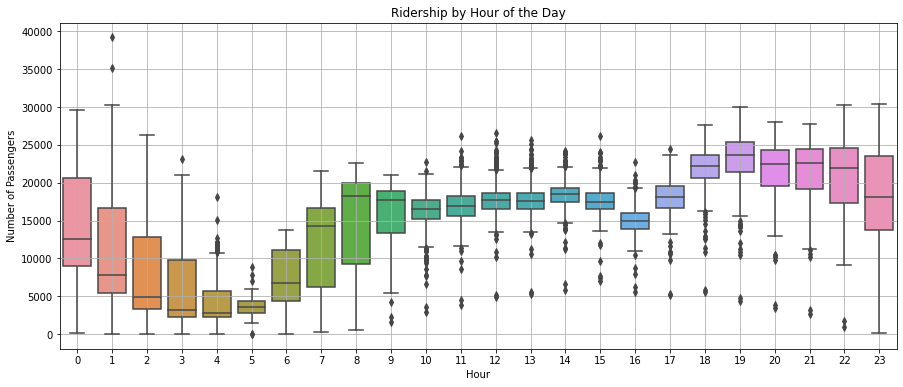

In [ ]:
# Visualize taxi ridership by hour of the day
plt.figure(figsize=(15, 6))
sns.boxplot(x='hour', y='value', data=df)
plt.title('Ridership by Hour of the Day')
plt.xlabel('Hour')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()

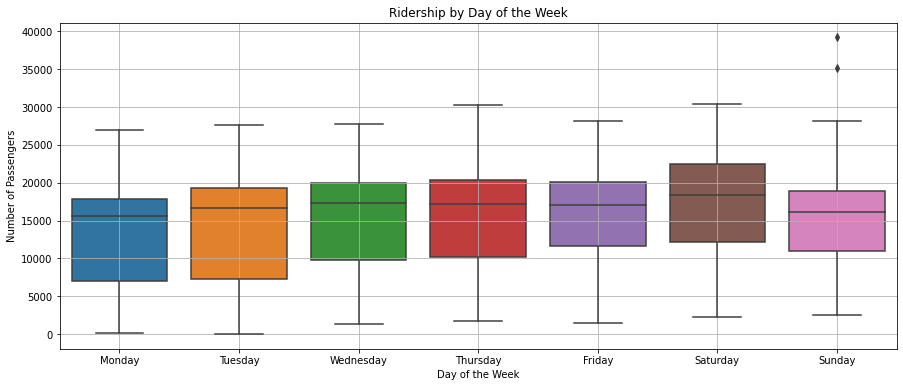

In [ ]:
# Visualize taxi ridership by day of the week
plt.figure(figsize=(15, 6))
sns.boxplot(x='day_of_week', y='value', data=df)
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Ridership by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()

Looking at the "NYC Taxi Ridership by Hour of the Day" boxplot, we observe that the median number of passengers is lowest in the early morning (around 5 AM) and peaks in the late evening (around 7 PM). This pattern aligns with the daily rhythms of the city, with fewer people traveling in the early morning and increased travel during the evening rush hour. 

There are also noticeable outliers during certain hours, which could correspond to anomalous events.The "NYC Taxi Ridership by Day of the Week" boxplot reveals that taxi demand is relatively stable from Monday to Friday but drops significantly on Saturdays and Sundays. This pattern likely reflects the reduced commuter travel and overall slower pace of the city during the weekends. 

Again, there are several outliers on certain days, which could represent anomalies in our data.

Armed with these insights, we can now proceed to the next phase of our project: building our anomaly detection models.




### Building an anomaly detection model



We'll build anomaly detection models using Isolation Forest and One-Class SVM, two powerful techniques for identifying outliers in data. Doing two different model types will let us compare their accuracy to decide which is most useful.



In [ ]:
from sklearn.model_selection import train_test_split

# Extract the target variable
y = df['value'].values

# Perform the train-test split
train_size = int(len(y) * 0.75)
X_train, X_test = y[:train_size], y[train_size:]

# Convert the data into the right shape for our models
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

# Check the size of our training and test sets
X_train.shape, X_test.shape

((7740, 1), (2580, 1))

**Isolation Forest**

The Isolation Forest algorithm isolates observations by randomly selecting a feature and then randomly selecting a split value between the maximum and minimum values of the selected feature. The logic argument goes: isolating anomaly observations is easier because only a few conditions are needed to separate those cases from the normal observations. On the other hand, isolating normal observations require more conditions. Therefore, an anomaly score can be calculated as the number of conditions required to separate a given observation.We'll start by training an Isolation Forest model on our data.



In [ ]:
from sklearn.ensemble import IsolationForest

# Instantiate the Isolation Forest model
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# Fit the model to our training data
iso_forest.fit(X_train)

IsolationForest(contamination=0.05, random_state=42) In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook. On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org. IsolationForest IsolationForest(contamination=0.05, random_state=42)

The Isolation Forest model has been successfully trained on our data. The `**contamination**` parameter is set to 0.05, which means that we expect about 5% of our data to be anomalies. This is a rough estimate; in practice, the exact proportion of anomalies is often unknown.Next, let's build our second anomaly detection model using the One-Class SVM algorithm.



**One-Class SVM**

One-Class SVM is an algorithm that computes a decision function that is supposed to capture the region in which the training data lives. This algorithm is particularly useful for anomaly detection because it allows us to identify data points that lie outside this region. Here, we'll train a One-Class SVM model on our data.



In [ ]:
from sklearn.svm import OneClassSVM

# Instantiate the One-Class SVM model
one_class_svm = OneClassSVM(kernel='rbf', nu=0.05, gamma=0.01)

# Fit the model to our training data
one_class_svm.fit(X_train)

OneClassSVM(gamma=0.01, nu=0.05) In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook. On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org. OneClassSVM OneClassSVM(gamma=0.01, nu=0.05)

The One-Class SVM model has been successfully trained on our data. The `**nu**` parameter, similar to the `**contamination**` parameter in the Isolation Forest model, is set to 0.05, indicating that we expect about 5% of our data to be anomalies.With both our models trained, we can now proceed to the next step of our project: evaluating the models and identifying anomalies in our test data.




### Model evaluation

We'll evaluate the performance of our models on the test set. We'll compute the anomaly scores for our test data using each model, and then classify data points as normal or anomalous based on these scores.



In [ ]:
# Use the Isolation Forest model to compute anomaly scores for our test data
iso_forest_scores = iso_forest.decision_function(X_test)

# Classify data points as normal (1) or anomalous (-1)
iso_forest_preds = iso_forest.predict(X_test)

# Use the One-Class SVM model to compute anomaly scores for our test data
one_class_svm_scores = one_class_svm.decision_function(X_test)

# Classify data points as normal (1) or anomalous (-1)
one_class_svm_preds = one_class_svm.predict(X_test)

# Convert the predictions from 1/-1 to 0/1 for easier interpretation
iso_forest_preds = (iso_forest_preds == -1).astype(int)
one_class_svm_preds = (one_class_svm_preds == -1).astype(int)

# Check the number of anomalies detected by each model
iso_forest_anomalies = iso_forest_preds.sum()
one_class_svm_anomalies = one_class_svm_preds.sum()

iso_forest_anomalies, one_class_svm_anomalies

(168, 1283)

Our Isolation Forest model identified 168 anomalies in the test data, while the One-Class SVM model identified a significantly higher number of anomalies - 1,283 in total.This discrepancy between the two models is a good illustration of the inherent uncertainty involved in anomaly detection. Different models, even when trained on the same data, can come to very different conclusions about which data points are considered "normal" and which are "anomalous".

Let's investigate these anomalies and attempt to align them with known events or significant deviations from the norm.



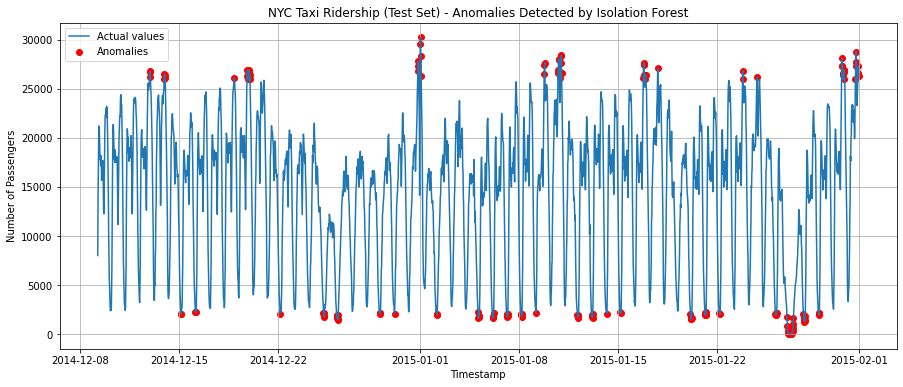

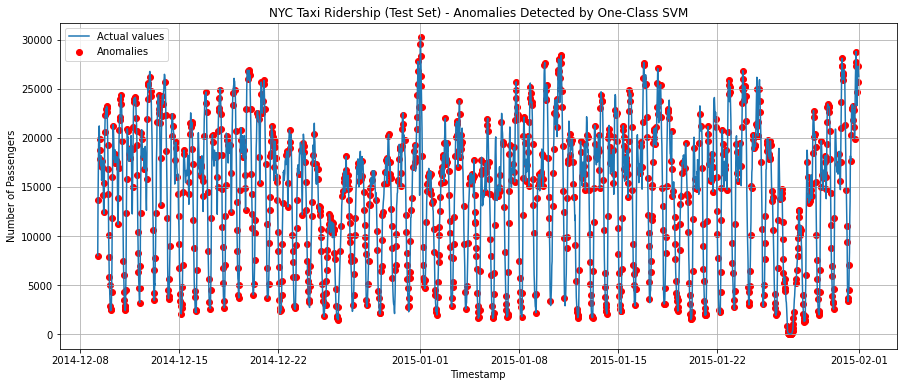

In [ ]:
# Create a DataFrame to store the test data and the predictions from our models
test_df = df.iloc[train_size:]
test_df['timestamp'] = test_df.index
test_df['iso_forest_preds'] = iso_forest_preds
test_df['one_class_svm_preds'] = one_class_svm_preds

# Plot the test data along with the anomalies detected by the Isolation Forest model
plt.figure(figsize=(15, 6))
plt.plot(test_df.index, test_df['value'], label='Actual values')
plt.scatter(test_df[test_df['iso_forest_preds'] == 1].index, test_df[test_df['iso_forest_preds'] == 1]['value'], color='red', label='Anomalies')
plt.title('NYC Taxi Ridership (Test Set) - Anomalies Detected by Isolation Forest')
plt.xlabel('Timestamp')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

# Plot the test data along with the anomalies detected by the One-Class SVM model
plt.figure(figsize=(15, 6))
plt.plot(test_df.index, test_df['value'], label='Actual values')
plt.scatter(test_df[test_df['one_class_svm_preds'] == 1].index, test_df[test_df['one_class_svm_preds'] == 1]['value'], color='red', label='Anomalies')
plt.title('NYC Taxi Ridership (Test Set) - Anomalies Detected by One-Class SVM')
plt.xlabel('Timestamp')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

The red dots on the plots represent the anomalies detected by our models. As we can see, the Isolation Forest model detected a smaller number of anomalies, primarily focusing on the most significant spikes in the data. On the other hand, the One-Class SVM model detected a much larger number of anomalies, many of which correspond to less dramatic deviations from the norm. We're less interested in these smaller deviations, since there's more noise/signal. We'll use the Isolation Forest model for any future work.

Upon inspection, we see that a number of these anomalies coincide with known city-wide events!

For instance, the sharp increase in taxi ridership on November 27th, 2014, corresponds to Thanksgiving Day, a major holiday in the United States when many people travel to celebrate with their families. Similarly, the spike on December 31st, 2014, aligns with New Year's Eve, another occasion when many people are out celebrating.

However, not all anomalies can be easily explained by known events. Some might correspond to less obvious factors, like changes in weather (there's a major snowstorm during this time), while others could be the result of data errors or other unknown influences. 



In [ ]:
new_df = test_df.copy()
new_df["iso_forest_anomalies"] = new_df.apply(
    lambda row: row["value"] if row["iso_forest_preds"] == 1 else None, axis=1
)


In [ ]:
import altair
chart_new_df = altair.Chart.from_json(r"""
{
    "width": "container",
    "height": "container",
    "$schema": "https://vega.github.io/schema/vega-lite/v5.json",
    "layer": [
        {
            "description": "outer data layer",
            "resolve": {
                "scale": {
                    "color": "independent",
                    "y": "shared"
                }
            },
            "layer": [
                {
                    "description": "series data layer",
                    "name": "series_9a8309a8-12b0-4e35-ae10-3f718a811a31",
                    "layer": [
                        {
                            "description": "line series layer",
                            "transform": [
                                {
                                    "calculate": "toDate(datum[\"timestamp\"])",
                                    "as": "timestamp"
                                },
                                {
                                    "filter": "isValid(datum[\"timestamp\"])"
                                }
                            ],
                            "layer": [
                                {
                                    "description": "line mark layer",
                                    "mark": {
                                        "type": "line",
                                        "point": false,
                                        "clip": true,
                                        "strokeCap": "square",
                                        "strokeJoin": "round",
                                        "cursor": "crosshair"
                                    },
                                    "encoding": {
                                        "opacity": {
                                            "value": 1
                                        }
                                    }
                                },
                                {
                                    "description": "pivot tooltip point mark layer",
                                    "mark": {
                                        "type": "point",
                                        "tooltip": true,
                                        "clip": true
                                    },
                                    "encoding": {
                                        "opacity": {
                                            "value": 0,
                                            "condition": {
                                                "param": "pivot_hover_9a8309a8-12b0-4e35-ae10-3f718a811a31",
                                                "value": 1,
                                                "empty": false
                                            }
                                        },
                                        "size": {
                                            "value": 80
                                        },
                                        "tooltip": [
                                            {
                                                "field": "timestamp",
                                                "type": "temporal",
                                                "timeUnit": "yearmonthdatehours",
                                                "title": "Timestamp"
                                            },
                                            {
                                                "field": "value",
                                                "type": "quantitative",
                                                "aggregate": "sum",
                                                "formatType": "NUMBER_FORMATTER",
                                                "format": {
                                                    "format": "NUMBER",
                                                    "columnType": "NUMBER",
                                                    "numDecimalDigits": -1,
                                                    "currency": "USD",
                                                    "nanFormat": ""
                                                },
                                                "title": "Actual values"
                                            }
                                        ]
                                    },
                                    "params": [
                                        {
                                            "name": "pivot_hover_9a8309a8-12b0-4e35-ae10-3f718a811a31",
                                            "select": {
                                                "type": "point",
                                                "on": "mouseover",
                                                "clear": "mouseout",
                                                "nearest": false,
                                                "fields": [
                                                    "timestamp"
                                                ]
                                            }
                                        }
                                    ]
                                }
                            ],
                            "encoding": {
                                "x": {
                                    "field": "timestamp",
                                    "type": "temporal",
                                    "title": "Timestamp",
                                    "scale": {
                                        "padding": 8
                                    },
                                    "axis": {
                                        "grid": true,
                                        "ticks": true,
                                        "tickCount": {
                                            "expr": "length(domain('x')) > 0 ? min(ceil(width / 40), ceil((domain('x')[1] - domain('x')[0]) / 3600000)) : ceil(width / 40)"
                                        },
                                        "labels": true,
                                        "labelFlush": false
                                    },
                                    "timeUnit": "yearmonthdatehours"
                                },
                                "y": {
                                    "field": "value",
                                    "type": "quantitative",
                                    "aggregate": "sum",
                                    "title": "Ridership ##",
                                    "scale": {},
                                    "axis": {
                                        "grid": true,
                                        "ticks": true,
                                        "labels": true,
                                        "labelFlush": false,
                                        "format": {
                                            "format": "NUMBER",
                                            "columnType": "NUMBER",
                                            "numDecimalDigits": -1,
                                            "currency": "USD",
                                            "nanFormat": ""
                                        },
                                        "formatType": "NUMBER_FORMATTER"
                                    }
                                },
                                "color": {
                                    "datum": "Actual values",
                                    "scale": {
                                        "range": [
                                            "#4C78A8",
                                            "#4C78A8"
                                        ]
                                    },
                                    "legend": {
                                        "symbolOpacity": 1,
                                        "symbolType": "stroke"
                                    }
                                }
                            }
                        }
                    ]
                },
                {
                    "description": "series data layer",
                    "name": "series_87c1e623-829e-4542-94b2-34ac7ae78cf1",
                    "layer": [
                        {
                            "description": "scatter series layer",
                            "transform": [
                                {
                                    "calculate": "toDate(datum[\"timestamp\"])",
                                    "as": "timestamp"
                                },
                                {
                                    "filter": "isValid(datum[\"timestamp\"])"
                                }
                            ],
                            "layer": [
                                {
                                    "layer": [
                                        {
                                            "description": "scatter point mark layer",
                                            "mark": {
                                                "type": "point",
                                                "filled": true,
                                                "clip": true,
                                                "cursor": "crosshair"
                                            },
                                            "encoding": {}
                                        }
                                    ],
                                    "encoding": {
                                        "color": {
                                            "datum": "Anomalies",
                                            "scale": {
                                                "range": [
                                                    "#F58518",
                                                    "#F58518"
                                                ]
                                            },
                                            "legend": {
                                                "symbolOpacity": 1
                                            }
                                        },
                                        "opacity": {
                                            "value": 1
                                        }
                                    }
                                },
                                {
                                    "description": "scatter tooltip point mark layer",
                                    "mark": {
                                        "type": "point",
                                        "filled": true,
                                        "clip": true,
                                        "cursor": "crosshair"
                                    },
                                    "encoding": {
                                        "color": {
                                            "value": "#F58518"
                                        },
                                        "tooltip": [
                                            {
                                                "field": "timestamp",
                                                "type": "temporal",
                                                "timeUnit": "yearmonthdatehours",
                                                "title": "Timestamp"
                                            },
                                            {
                                                "field": "iso_forest_anomalies",
                                                "type": "quantitative",
                                                "aggregate": "sum",
                                                "formatType": "NUMBER_FORMATTER",
                                                "format": {
                                                    "format": "NUMBER",
                                                    "columnType": "NUMBER",
                                                    "numDecimalDigits": -1,
                                                    "currency": "USD",
                                                    "nanFormat": ""
                                                },
                                                "title": "Anomalies"
                                            }
                                        ],
                                        "opacity": {
                                            "value": 0,
                                            "condition": {
                                                "param": "point_hover_87c1e623-829e-4542-94b2-34ac7ae78cf1",
                                                "value": 1,
                                                "empty": false
                                            }
                                        },
                                        "size": {
                                            "value": 100
                                        }
                                    },
                                    "params": [
                                        {
                                            "name": "point_hover_87c1e623-829e-4542-94b2-34ac7ae78cf1",
                                            "select": {
                                                "type": "point",
                                                "on": "mouseover",
                                                "nearest": false
                                            }
                                        }
                                    ]
                                }
                            ],
                            "encoding": {
                                "x": {
                                    "field": "timestamp",
                                    "type": "temporal",
                                    "title": "Timestamp",
                                    "scale": {
                                        "padding": 8
                                    },
                                    "axis": {
                                        "grid": true,
                                        "ticks": true,
                                        "tickCount": {
                                            "expr": "length(domain('x')) > 0 ? min(ceil(width / 40), ceil((domain('x')[1] - domain('x')[0]) / 3600000)) : ceil(width / 40)"
                                        },
                                        "labels": true,
                                        "labelFlush": false
                                    },
                                    "timeUnit": "yearmonthdatehours"
                                },
                                "y": {
                                    "field": "iso_forest_anomalies",
                                    "type": "quantitative",
                                    "aggregate": "sum",
                                    "title": "Ridership ##",
                                    "scale": {},
                                    "axis": {
                                        "grid": true,
                                        "ticks": true,
                                        "labels": true,
                                        "labelFlush": false,
                                        "format": {
                                            "format": "NUMBER",
                                            "columnType": "NUMBER",
                                            "numDecimalDigits": -1,
                                            "currency": "USD",
                                            "nanFormat": ""
                                        },
                                        "formatType": "NUMBER_FORMATTER"
                                    }
                                }
                            }
                        }
                    ]
                }
            ],
            "transform": []
        }
    ],
    "config": {
        "legend": {
            "orient": "right"
        },
        "font": "\"IBM Plex Sans\", system-ui, -apple-system, BlinkMacSystemFont, sans-serif",
        "view": {}
    },
    "datasets": {
        "layer00": [
            {
                "name": "dummy",
                "value": 0
            }
        ]
    },
    "usermeta": {
        "selectionConfigs": {},
        "columnNameMappings": {
            "CHART_FOLD_KEYS": "Column",
            "CHART_FOLD_VALUES": "Values"
        }
    }
}
""")
chart_new_df.datasets.layer00 = new_df.to_json(orient='records')
chart_new_df.display(actions=False)

While both models - the Isolation Forest and the One-Class SVM - were successful in detecting anomalies, they did so in slightly different ways, underscoring the inherent complexity and uncertainty involved in anomaly detection. The isolation forest model was better suited to our task of identifying high level anomalies in the data mapped to real-world events.

